In [1]:
#Import needed   libraries
import pandas as pd
import numpy as np
import string
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('AI-based Career Recommendation System.csv')
# Check columns and data types
print(df.info())

# Summary statistics
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CandidateID           200 non-null    int64  
 1   Name                  200 non-null    object 
 2   Age                   200 non-null    int64  
 3   Education             200 non-null    object 
 4   Skills                200 non-null    object 
 5   Interests             200 non-null    object 
 6   Recommended_Career    200 non-null    object 
 7   Recommendation_Score  200 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 12.6+ KB
None
       CandidateID         Age  Recommendation_Score
count   200.000000  200.000000            200.000000
mean    100.500000   30.125000              0.896450
std      57.879185    4.923472              0.028915
min       1.000000   22.000000              0.850000
25%      50.750000   26.750000              0.870000


In [2]:
df.head()

,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,1,John Doe,28,Bachelor's,Python;Data Analysis;Machine Learning,Technology;Data Science,Data Scientist,0.95
1,2,Jane Smith,32,Master's,Java;System Design;Cloud Computing,Software Development;AI,Software Engineer,0.90
2,3,Bob Johnson,24,Bachelor's,Graphic Design;UI/UX;Adobe Creative Suite,Arts;Digital Media,UX Designer,0.88
3,4,Emily Davis,26,Bachelor's,Python;Deep Learning;Statistics,Healthcare;AI,AI Researcher,0.93
4,5,Michael Brown,30,Master's,Project Management;Communication;Agile,Business;Management,Project Manager,0.87


In [3]:
print(df['Skills'].unique())

['Python;Data Analysis;Machine Learning'
 'Java;System Design;Cloud Computing'
 'Graphic Design;UI/UX;Adobe Creative Suite'
 'Python;Deep Learning;Statistics'
 'Project Management;Communication;Agile' 'C++;Embedded Systems;IoT'
 'SQL;Data Warehousing;ETL' 'Content Writing;SEO;Social Media'
 'Python;Natural Language Processing;Machine Learning'
 'Financial Analysis;Excel;Econometrics'
 'Research;Statistical Analysis;Python' 'HTML;CSS;JavaScript'
 'Java;Algorithms;Data Structures' 'Data Visualization;Python;R'
 'Machine Learning;Big Data;Python'
 'Digital Marketing;Content Creation;SEO' 'Python;Data Mining;Statistics'
 'C#;.NET;Software Design' 'Project Management;Risk Analysis;Negotiation'
 'User Research;UX Design;Prototyping' 'Python;Data Analysis;SQL'
 'Marketing Strategy;Digital Marketing;CRM' 'JavaScript;React;Node.js'
 'Data Science;Machine Learning;Python' 'Network Security;Linux;Python'
 'Python;Statistics;Data Mining' 'Cloud Computing;DevOps;Python'
 'Content Creation;Graphic D

In [4]:
df.drop(columns=['CandidateID'], inplace=True)

In [5]:
#Data Pre processing
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
df['Skills'] = df['Skills'].str.lower()
df['Interests'] = df['Interests'].str.lower()
df['Recommended_Career'] = df['Recommended_Career'].str.lower()
# Optional: just for readability
df['Skills'] = df['Skills'].str.replace(';', ' > ')
df['Interests'] = df['Interests'].str.replace(';', ' > ')
df['Recommended_Career'] = df['Recommended_Career'].str.replace(';', ' > ')
df['Education'] = df['Education'].str.replace(f'[{string.punctuation}]', '',  regex=True)
print(df.duplicated().sum())

0


In [6]:
df.head(15)
cleaned_df = df

In [7]:
def Smart_Career_Recommendation(career_df):
    '''
    A smart creer recommendation systtem that recommends to users a career path they should based on some personalised qualities and interest of the user
    :param df: A dataset that coontains some personalised features or interests of users. It has columns like 'Knowledge', 'Interest', etc
    :return:
    list:  list of recommended career  paths
    '''
    tfidf_skills = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_df=0.9,min_df=2,sublinear_tf=True)
    tfidf_interests = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_df=0.9,min_df=2,sublinear_tf=True)
    tfidf_edu = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_df=0.9,min_df=2,sublinear_tf=True)
#Matrices for the features of the dataset
    skills_matrix = tfidf_skills.fit_transform(df['Skills'])
    interests_matrix = tfidf_interests.fit_transform(df['Interests'])
    edu_matrix = tfidf_edu.fit_transform(df['Education'])
    print(f'model trained on {len(career_df)} data points')
    while True:
        print("\nEnter 'quit' anytime to exit.\n")
        #Allowed   use  inputs for prediction
        u_interests = input('Enter Area of  Interests in the tech field: ').strip().lower()
        if u_interests.lower() == 'quit':
            print("Exiting...")
            break
        u_skills = input('Enter Skills  you have in the tech field: ').strip().lower()
        if u_skills.lower() == 'quit':
            print("Exiting...")
            break
        u_education = input('Enter Education  level in study: ')
        if u_education.lower() == 'quit':
            print("Exiting...")
            break
            #Vectorise use inputs using the tfid of the dataset
        u_skills_vec = tfidf_skills.transform([u_skills])
        u_interest_vec = tfidf_interests.transform([u_interests])
        u_edu_vec = tfidf_edu.transform([u_education])
        # Compute similarity separately
        skills_sim = cosine_similarity(u_skills_vec, skills_matrix).flatten()
        interest_sim = cosine_similarity(u_interest_vec, interests_matrix).flatten()
        edu_sim = cosine_similarity(u_edu_vec, edu_matrix).flatten()
        final_score = (0.6 * skills_sim) + (0.3 * interest_sim) + (0.1 * edu_sim)
        sim_score = list(enumerate(final_score))
        sim_score= sorted(sim_score, key=lambda x: x[1], reverse=True)[1:11]
        top_idx = [i[0] for i in sim_score]
        rec_career = df.iloc[top_idx]['Recommended_Career'].values
        recommended_df = pd.DataFrame({
            'Career': rec_career,
            'Skills Match %': (skills_sim[top_idx] * 100).round(2),
            'Interest Match %': (interest_sim[top_idx] * 100).round(2),
            'Education Match %': (edu_sim[top_idx] * 100).round(2),
            'Final Score %': (final_score[top_idx] * 100).round(2)
            })
        recommended_df = recommended_df.sort_values('Final Score %', ascending=False).drop_duplicates(subset=['Career']).reset_index(drop=True)
        print("\n Top Recommended Career Paths for You:")
        print(recommended_df.to_string(index=False))
        plt.figure(figsize=(8, 4))
        sns.barplot(x='Career', y='Final Score %', data=recommended_df)
        plt.title("Top Career Recommendations")
        plt.xticks(rotation=75)
        plt.tight_layout()
        plt.show()
    sim_df = pd.DataFrame({
    "Skills": skills_sim,
    "Interests": interest_sim,
    "Education": edu_sim
    })
    sns.heatmap(sim_df.corr(), annot=True)
    plt.title("Similarity Factors Correlation")
    plt.show()
    print('Goodluck in your recommended career paths')




model trained on 200 data points

Enter 'quit' anytime to exit.


 Top Recommended Career Paths for You:
                  Career  Skills Match %  Interest Match %  Education Match %  Final Score %
    full stack developer           38.89              0.00              100.0          33.33
         devops engineer           38.89              0.00              100.0          33.33
            data analyst           38.89              0.00              100.0          33.33
            nlp engineer            0.00            100.00                0.0          30.00
           ai researcher            0.00             50.01              100.0          25.00
           ai specialist            0.00             50.01              100.0          25.00
        graphic designer            0.00             50.01              100.0          25.00
cybersecurity specialist           38.89              0.00                0.0          23.33


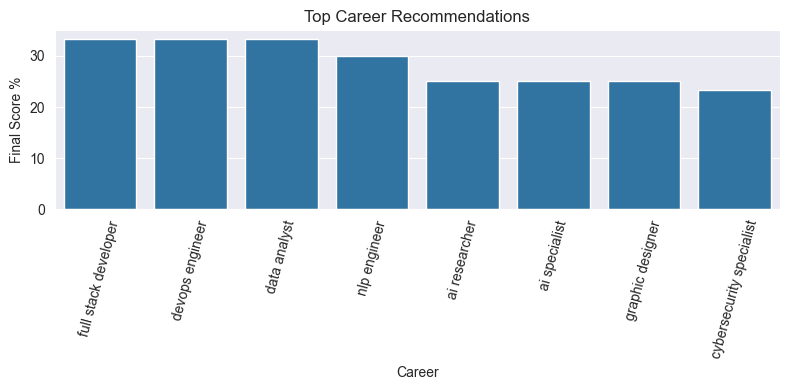


Enter 'quit' anytime to exit.



KeyboardInterrupt: Interrupted by user

In [8]:
Smart_Career_Recommendation(df)

In [10]:
import os
import joblib
#Here saved the vectorizers and the matrices for the trained model or the dataset trained with it in order to compute with similarity in the web app after collecting user inputs
tfidf_skills = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_df=0.9,min_df=2,sublinear_tf=True)
tfidf_interests = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_df=0.9,min_df=2,sublinear_tf=True)
tfidf_edu = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_df=0.9,min_df=2,sublinear_tf=True)

skills_matrix = tfidf_skills.fit_transform(df['Skills'])
interests_matrix = tfidf_interests.fit_transform(df['Interests'])
edu_matrix = tfidf_edu.fit_transform(df['Education'])

os.makedirs('smart_career_models', exist_ok=True)
joblib.dump(tfidf_skills, "smart_career_models/tfidf_skills.pkl")
joblib.dump(tfidf_interests, "smart_career_models/tfidf_interests.pkl")
joblib.dump(tfidf_edu, "smart_career_models/tfidf_edu.pkl")
joblib.dump(skills_matrix, "smart_career_models/skills_matrix.pkl")
joblib.dump(interests_matrix, "smart_career_models/interests_matrix.pkl")
joblib.dump(edu_matrix, "smart_career_models/edu_matrix.pkl")

['smart_career_models/edu_matrix.pkl']